# Proyecto Final - Notebook 01
## EDA y preprocesamiento para image captioning

Este notebook cubre las primeras etapas de la rubrica del curso:
1. Descripcion del problema.
2. Exploracion y entendimiento de los datos.
3. Preparacion de los datos para alimentar modelos de deep learning.

La idea es trabajar con `Flickr8k`, revisar la estructura del dataset, limpiar los captions y dejar listos:
- un split reproducible por imagen,
- captions limpios,
- tokenizer inicial del decoder,
- artefactos guardados en `data/processed/`.


In [1]:
from pathlib import Path
import os
import json
import pickle
import re
from tempfile import gettempdir

os.environ.setdefault('MPLCONFIGDIR', str(Path(gettempdir()) / 'matplotlib-cache-project-final'))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.image import imread
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer


c:\Users\Daniel Martinez\AppData\Local\Programs\Python\Python313\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/attr_value.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
c:\Users\Daniel Martinez\AppData\Local\Programs\Python\Python313\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/tensor.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
c:\Users\Daniel Martinez\AppData\Local\Programs\Python\Python313\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.3

In [2]:
# Resolver rutas de forma robusta para que el notebook funcione tanto
# si se abre desde `notebooks/` como si se ejecuta desde la raiz del proyecto.
ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
RAW_DIR = ROOT / 'data' / 'raw'
IMG_DIR = RAW_DIR / 'Images'
CAPTIONS_PATH = RAW_DIR / 'captions.txt'
PROCESSED_DIR = ROOT / 'data' / 'processed'
FIGURES_DIR = ROOT / 'outputs' / 'figures'

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print('ROOT =', ROOT)
print('CAPTIONS_PATH =', CAPTIONS_PATH)
print('IMG_DIR exists =', IMG_DIR.exists())
print('CAPTIONS exists =', CAPTIONS_PATH.exists())


ROOT = C:\Users\Daniel Martinez\Desktop\Dee Learning\Proccesador de imagenes\Trabajo_final_deep_learning
CAPTIONS_PATH = C:\Users\Daniel Martinez\Desktop\Dee Learning\Proccesador de imagenes\Trabajo_final_deep_learning\data\raw\captions.txt
IMG_DIR exists = False
CAPTIONS exists = False


In [4]:
df = pd.read_csv(CAPTIONS_PATH)
df.head()


,image,caption
0,1000268201_693b08cb0e.jpg,A child in a pink dress is climbing up a set o...
1,1000268201_693b08cb0e.jpg,A girl going into a wooden building .
2,1000268201_693b08cb0e.jpg,A little girl climbing into a wooden playhouse .
3,1000268201_693b08cb0e.jpg,A little girl climbing the stairs to her playh...
4,1000268201_693b08cb0e.jpg,A little girl in a pink dress going into a woo...


In [5]:
# Resumen basico del dataset para validar consistencia entre imagenes y captions.
num_images_disk = len(list(IMG_DIR.glob('*.jpg')))
num_caption_rows = len(df)
num_unique_images = df['image'].nunique()
caption_counts = df.groupby('image').size()

summary = {
    'num_images_disk': int(num_images_disk),
    'num_caption_rows': int(num_caption_rows),
    'num_unique_images_in_captions': int(num_unique_images),
    'captions_per_image_min': int(caption_counts.min()),
    'captions_per_image_max': int(caption_counts.max()),
    'captions_per_image_mean': float(caption_counts.mean()),
}
summary


{'num_images_disk': 8091,
 'num_caption_rows': 40455,
 'num_unique_images_in_captions': 8091,
 'captions_per_image_min': 5,
 'captions_per_image_max': 5,
 'captions_per_image_mean': 5.0}

## Revision visual rapida

La siguiente celda muestra algunas imagenes con uno de sus captions para validar que la carga del dataset es consistente.


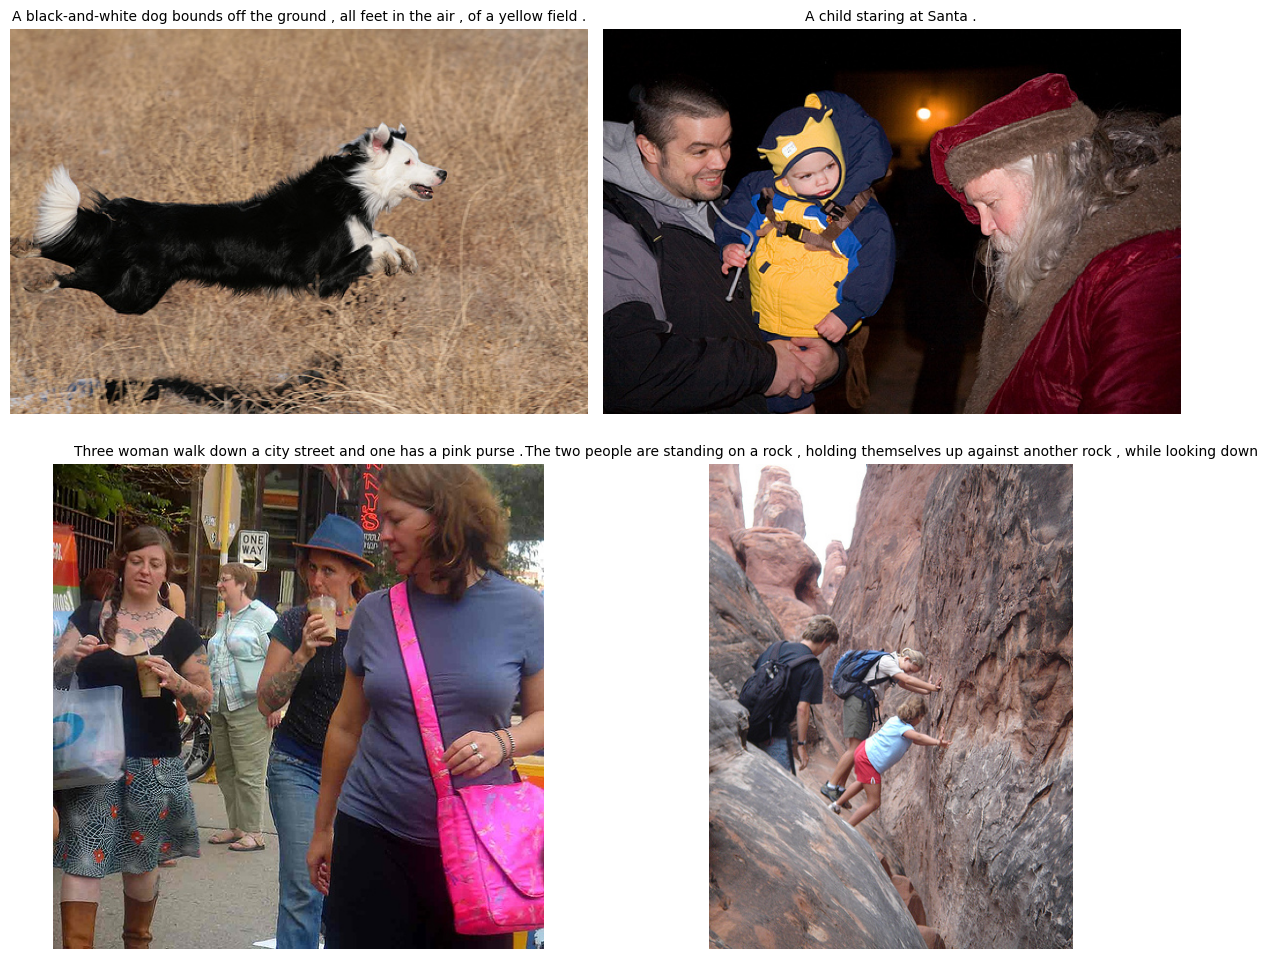

In [6]:
sample_images = df['image'].drop_duplicates().sample(4, random_state=42).tolist()
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()

for ax, img_name in zip(axes, sample_images):
    img = imread(IMG_DIR / img_name)
    caption = df.loc[df['image'] == img_name, 'caption'].iloc[0]
    ax.imshow(img)
    ax.set_title(caption, fontsize=10)
    ax.axis('off')

plt.tight_layout()
plt.show()


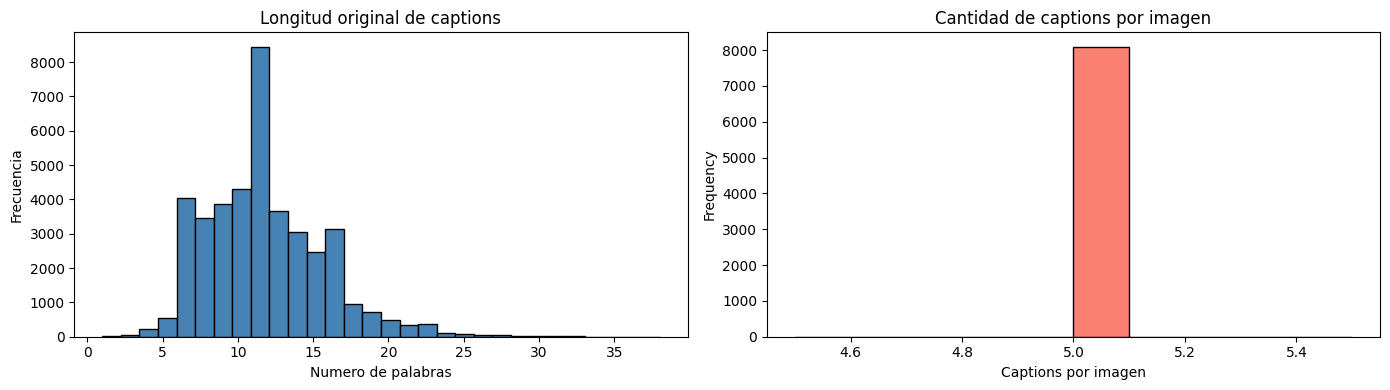

In [6]:
df['raw_caption_len_words'] = df['caption'].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(df['raw_caption_len_words'], bins=30, color='steelblue', edgecolor='black')
axes[0].set_title('Longitud original de captions')
axes[0].set_xlabel('Numero de palabras')
axes[0].set_ylabel('Frecuencia')

caption_counts.plot(kind='hist', bins=10, color='salmon', edgecolor='black', ax=axes[1])
axes[1].set_title('Cantidad de captions por imagen')
axes[1].set_xlabel('Captions por imagen')

plt.tight_layout()
plt.show()


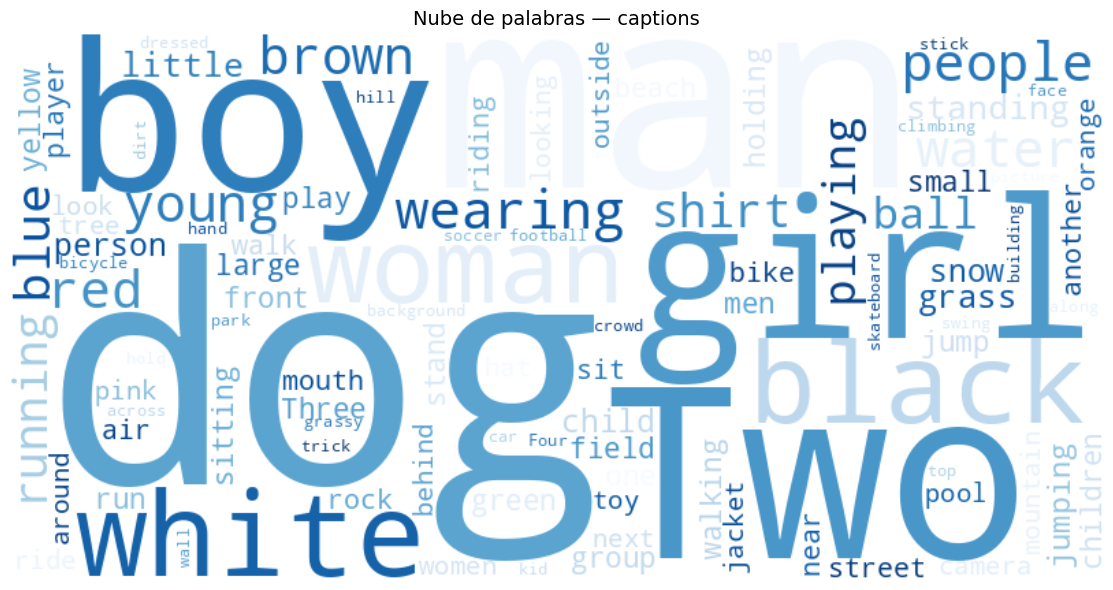

In [7]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud
 
# ─── Reemplaza esto con tu DataFrame real ──────────────────────────────────────
# full_text = " ".join(df["caption"])
 
# Datos de ejemplo:

full_text = " ".join(df["caption"]) 
 
# ─── Nube de palabras ───────────────────────────────────────────────────────────
wc = WordCloud(
    width=800,
    height=400,
    background_color="white",
    max_words=100,
    colormap="Blues",
    collocations=False,
    random_state=42,
)
wc.generate(full_text)
 
fig, ax = plt.subplots(figsize=(12, 6))
ax.imshow(wc, interpolation="bilinear")
ax.axis("off")
ax.set_title("Nube de palabras — captions", fontsize=14)
 
plt.tight_layout()
plt.savefig("wordcloud_captions.png", dpi=150, bbox_inches="tight")
plt.show()

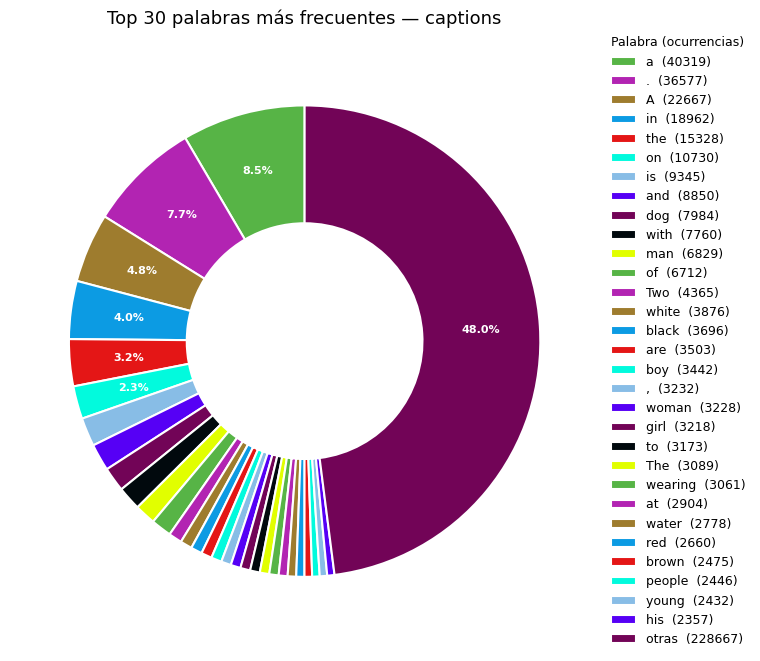

In [ ]:
from collections import Counter
import matplotlib.pyplot as plt
 

# full_text = " ".join(df["caption"])
 
# Datos de ejemplo:
full_text = " ".join(df["caption"])

top_n = 30
word_freq = Counter(full_text.split())
top_words = word_freq.most_common(top_n)
labels, values = zip(*top_words)
 
# Agrupar el resto como "Otras"
total = sum(word_freq.values())
top_total = sum(values)
otros = total - top_total
labels = list(labels) + ["otras"]
values = list(values) + [otros]
 
# ─── Colores ────────────────────────────────────────────────────────────────────
colors = [
    "#57B446", "#B224B2", "#9E7C2E", "#0C9BE3", "#E41616",
    "#02FADD", "#88BDE6", "#5600F5", "#720457", "#01090D",
    "#E1FF00",  # gris para "otras"
]
 
# ─── Gráfico de anillo ──────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 7))
 
wedges, texts, autotexts = ax.pie(
    values,
    labels=None,
    autopct=lambda p: f"{p:.1f}%" if p >= 2 else "",
    startangle=90,
    colors=colors,
    pctdistance=0.75,
    wedgeprops=dict(width=0.5, edgecolor="white", linewidth=1.5),
)
 
for at in autotexts:
    at.set_fontsize(8)
    at.set_color("white")
    at.set_fontweight("bold")
 
# Leyenda con conteo absoluto
legend_labels = [f"{l}  ({v})" for l, v in zip(labels, values)]
ax.legend(
    wedges,
    legend_labels,
    title="Palabra (ocurrencias)",
    loc="center left",
    bbox_to_anchor=(1.0, 0.5),
    fontsize=9,
    title_fontsize=9,
    frameon=False,
)
 
ax.set_title(f"Top {top_n} palabras más frecuentes — captions", fontsize=13, pad=16)
 
plt.tight_layout()
plt.savefig("top_words_anillo.png", dpi=150, bbox_inches="tight")
plt.show()

## Limpieza de captions

Para el baseline usaremos una limpieza simple y consistente:
- pasar a minusculas,
- remover caracteres no alfabeticos,
- compactar espacios,
- agregar tokens `startseq` y `endseq`.

La limpieza debe ser suficientemente simple para no destruir semantica y suficientemente estable para entrenar el decoder.


In [7]:
def clean_caption(text: str) -> str:
    # Normalizar a minusculas para reducir variaciones artificiales del vocabulario.
    text = text.lower().strip()
    # Mantener solo letras y espacios en el baseline para simplificar el decoder.
    text = re.sub(r"[^a-z\s]", " ", text)
    # Compactar espacios repetidos generados por la limpieza.
    text = re.sub(r"\s+", " ", text).strip()
    # Agregar tokens de inicio y fin para entrenar la generacion autoregresiva.
    return f'startseq {text} endseq'


# Aplicar la limpieza al caption original y recalcular su longitud util.
df['caption_clean'] = df['caption'].astype(str).apply(clean_caption)
df['clean_caption_len_words'] = df['caption_clean'].str.split().str.len()

df[['caption', 'caption_clean']].head()


,caption,caption_clean
0,A child in a pink dress is climbing up a set o...,startseq a child in a pink dress is climbing u...
1,A girl going into a wooden building .,startseq a girl going into a wooden building e...
2,A little girl climbing into a wooden playhouse .,startseq a little girl climbing into a wooden ...
3,A little girl climbing the stairs to her playh...,startseq a little girl climbing the stairs to ...
4,A little girl in a pink dress going into a woo...,startseq a little girl in a pink dress going i...


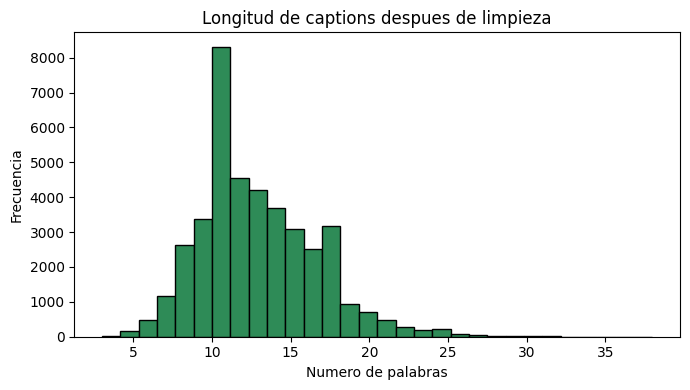

In [8]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(df['clean_caption_len_words'], bins=30, color='seagreen', edgecolor='black')
ax.set_title('Longitud de captions despues de limpieza')
ax.set_xlabel('Numero de palabras')
ax.set_ylabel('Frecuencia')
plt.tight_layout()
plt.show()


## Split reproducible por imagen

El split se hace a nivel de `image`, no a nivel de filas, para evitar fuga de informacion.
Cada imagen tiene varios captions; si una misma imagen quedara en train y test, la evaluacion quedaria contaminada.


In [9]:
# El split se hace por imagen y no por fila para evitar leakage:
# una misma imagen no puede quedar en train y test con captions distintos.
rng = np.random.default_rng(42)
unique_images = np.array(sorted(df['image'].unique()))
rng.shuffle(unique_images)

n_total = len(unique_images)
n_train = int(n_total * 0.7)
n_val = int(n_total * 0.15)

train_images = unique_images[:n_train]
val_images = unique_images[n_train:n_train + n_val]
test_images = unique_images[n_train + n_val:]

split_map = {}
for img in train_images:
    split_map[img] = 'train'
for img in val_images:
    split_map[img] = 'val'
for img in test_images:
    split_map[img] = 'test'

df['split'] = df['image'].map(split_map)
df['split'].value_counts()


split
train    28315
test      6075
val       6065
Name: count, dtype: int64

In [10]:
split_summary = df.groupby('split').agg(
    n_rows=('image', 'size'),
    n_unique_images=('image', 'nunique'),
    mean_caption_len=('clean_caption_len_words', 'mean')
).reset_index()

split_summary


,split,n_rows,n_unique_images,mean_caption_len
0,test,6075,1215,12.834403
1,train,28315,5663,12.803744
2,val,6065,1213,12.832976


## Tokenizacion inicial del decoder

El tokenizer se ajusta **solo con captions de entrenamiento** para reducir leakage hacia validacion y test.
Esto deja lista la base para el notebook de modelado.


In [11]:
# Ajustar el tokenizer solo con captions de train para no filtrar informacion
# de validacion o test hacia el vocabulario del modelo.
train_captions = df.loc[df['split'] == 'train', 'caption_clean'].tolist()
val_captions = df.loc[df['split'] == 'val', 'caption_clean'].tolist()
test_captions = df.loc[df['split'] == 'test', 'caption_clean'].tolist()

tokenizer = Tokenizer(oov_token='unk')
tokenizer.fit_on_texts(train_captions)

train_sequences = tokenizer.texts_to_sequences(train_captions)
val_sequences = tokenizer.texts_to_sequences(val_captions)
test_sequences = tokenizer.texts_to_sequences(test_captions)

# `vocab_size` incluye el indice 0 reservado para padding.
vocab_size = len(tokenizer.word_index) + 1
# `max_len` define la longitud maxima a la que se llevaran todas las secuencias.
max_len = max(len(seq) for seq in train_sequences)

print('vocab_size =', vocab_size)
print('max_len =', max_len)


vocab_size = 7251
max_len = 38


In [12]:
# Llevar todas las secuencias a la misma longitud para entrenar por lotes.
train_padded = pad_sequences(train_sequences, maxlen=max_len, padding='post')
val_padded = pad_sequences(val_sequences, maxlen=max_len, padding='post')
test_padded = pad_sequences(test_sequences, maxlen=max_len, padding='post')

print('train_padded shape =', train_padded.shape)
print('val_padded shape =', val_padded.shape)
print('test_padded shape =', test_padded.shape)


train_padded shape = (28315, 38)
val_padded shape = (6065, 38)
test_padded shape = (6075, 38)


## Guardado de artefactos

Se guardan los archivos base para los siguientes notebooks del proyecto.


In [13]:
# Guardar el dataframe limpio y los splits para reutilizarlos en modelado.
df.to_csv(PROCESSED_DIR / 'captions_clean_split.csv', index=False)

pd.Series(train_images).to_csv(PROCESSED_DIR / 'train_images.txt', index=False, header=False)
pd.Series(val_images).to_csv(PROCESSED_DIR / 'val_images.txt', index=False, header=False)
pd.Series(test_images).to_csv(PROCESSED_DIR / 'test_images.txt', index=False, header=False)

# Persistir el tokenizer en JSON evita problemas de compatibilidad entre versiones de Keras.
(PROCESSED_DIR / 'tokenizer.json').write_text(tokenizer.to_json(), encoding='utf-8')

# El pickle se conserva solo como respaldo local cuando se trabaja en el mismo entorno.
with open(PROCESSED_DIR / 'tokenizer.pkl', 'wb') as f:
    pickle.dump(tokenizer, f)

preprocess_summary = {
    'num_images_disk': int(num_images_disk),
    'num_caption_rows': int(num_caption_rows),
    'num_unique_images': int(num_unique_images),
    'train_unique_images': int(len(train_images)),
    'val_unique_images': int(len(val_images)),
    'test_unique_images': int(len(test_images)),
    'vocab_size': int(vocab_size),
    'max_len': int(max_len),
    'mean_raw_caption_len': float(df['raw_caption_len_words'].mean()),
    'mean_clean_caption_len': float(df['clean_caption_len_words'].mean())
}

with open(PROCESSED_DIR / 'preprocessing_summary.json', 'w', encoding='utf-8') as f:
    json.dump(preprocess_summary, f, indent=2)

print('Artefactos guardados en', PROCESSED_DIR)

Artefactos guardados en /Users/danilosuarezvargas/Documents/Maestria Universidad andes/Deep learning/Proyecto_Final_Captioning/data/processed


## Conclusiones del notebook 01

- El dataset quedo validado y estructurado para modelado.
- El split se hizo a nivel de imagen, evitando fuga de informacion.
- Los captions ya quedaron limpios y tokenizados para un primer baseline.
- El siguiente paso natural es extraer features visuales con una `CNN` preentrenada y entrenar el decoder `LSTM/GRU`.
